# Toy6 — Operador MT3DZ vs. SimPEG

Comparación de las dos respuestas MT calculadas para el **mismo** modelo, la misma malla, las
mismas frecuencias y el mismo receptor.

| Fuente | Archivos | Cuaderno que los genera |
|---|---|---|
| Operador MT3DZ | `impedance_MT3DZ_Toy6.npy`, `tipper_MT3DZ_Toy6.npy` | `MT_ModelToy6_MT3DZ.ipynb` |
| SimPEG | `impedance_SimPEG_Toy6.npy`, `tipper_SimPEG_Toy6.npy` | `MT_ModelToy6_SimPEG.ipynb` |

Este cuaderno **no vuelve a correr ningún modelamiento directo**: solo carga los `.npy`, compara
resistividad aparente, fase y tipper, y cuantifica la diferencia con MAE / RMSE / MAPE.

**Genera:** la figura `MT3DZ_vs_SimPEG_Toy6.png`.

> Ejecutar primero `MT_ModelToy6_MT3DZ.ipynb` y `MT_ModelToy6_SimPEG.ipynb`.

In [1]:
# 0) Importaciones y parametros del experimento
import numpy as np
import matplotlib.pyplot as plt

# Deben coincidir con los de los dos cuadernos de modelamiento
frequency_list = np.logspace(-4, 2, 3)

# Receptor a comparar
irec = 0

mu_0 = 4 * np.pi * 1e-7


def apparent_resistivity(Zcomp, frequencies):
    """Resistividad aparente a partir de una componente de Z."""
    omega = 2 * np.pi * np.asarray(frequencies)
    return np.abs(Zcomp) ** 2 / (mu_0 * omega)


def phase_deg(Zcomp):
    """Fase en grados."""
    return np.degrees(np.angle(Zcomp))

In [2]:
# 1) Carga de las dos respuestas

# Operador MT3DZ (Forward/MT3DZ.py -> compute_mt_responses)
impedance_op = np.load("impedance_MT3DZ_Toy6.npy")
tipper_op = np.load("tipper_MT3DZ_Toy6.npy")

# SimPEG (NSEM.Simulation3DPrimarySecondary)
impedance_sp = np.load("impedance_SimPEG_Toy6.npy")
tipper_sp = np.load("tipper_SimPEG_Toy6.npy")

print("Operador MT3DZ -> Z:", impedance_op.shape, "| T:", tipper_op.shape)
print("SimPEG         -> Z:", impedance_sp.shape, "| T:", tipper_sp.shape)
print("(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)")

assert impedance_op.shape == impedance_sp.shape, "Z: las formas no coinciden"
assert tipper_op.shape == tipper_sp.shape, "T: las formas no coinciden"
assert impedance_op.shape[1] == len(frequency_list), "n_freq no coincide con frequency_list"

Operador MT3DZ -> Z: (1, 3, 2, 2) | T: (1, 3, 2)
SimPEG         -> Z: (1, 3, 2, 2) | T: (1, 3, 2)
(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)


In [3]:
# 2) Resistividad aparente, fase y tipper de cada operador

# Frecuencias de menor a mayor, para que las curvas queden conectadas
orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# --- Impedancia: componentes XY / YX
Zxy_op = impedance_op[irec, orden, 0, 1]
Zyx_op = impedance_op[irec, orden, 1, 0]

Zxy_sp = impedance_sp[irec, orden, 0, 1]
Zyx_sp = impedance_sp[irec, orden, 1, 0]

rho_xy_op = apparent_resistivity(Zxy_op, frec)
rho_yx_op = apparent_resistivity(Zyx_op, frec)
rho_xy_sp = apparent_resistivity(Zxy_sp, frec)
rho_yx_sp = apparent_resistivity(Zyx_sp, frec)

phi_xy_op = phase_deg(Zxy_op)
phi_yx_op = phase_deg(Zyx_op)
phi_xy_sp = phase_deg(Zxy_sp)
phi_yx_sp = phase_deg(Zyx_sp)

# --- Tipper: componentes Tzx / Tzy
Tzx_op = tipper_op[irec, orden, 0]
Tzy_op = tipper_op[irec, orden, 1]

Tzx_sp = tipper_sp[irec, orden, 0]
Tzy_sp = tipper_sp[irec, orden, 1]

mag_tzx_op, mag_tzy_op = np.abs(Tzx_op), np.abs(Tzy_op)
mag_tzx_sp, mag_tzy_sp = np.abs(Tzx_sp), np.abs(Tzy_sp)

phi_tzx_op, phi_tzy_op = phase_deg(Tzx_op), phase_deg(Tzy_op)
phi_tzx_sp, phi_tzy_sp = phase_deg(Tzx_sp), phase_deg(Tzy_sp)

# --- Diferencias relativas respecto a SimPEG (%)
dif_Z_xy = np.abs(Zxy_op - Zxy_sp) / np.abs(Zxy_sp) * 100
dif_Z_yx = np.abs(Zyx_op - Zyx_sp) / np.abs(Zyx_sp) * 100

dif_T_zx = np.abs(Tzx_op - Tzx_sp) / np.abs(Tzx_sp) * 100
dif_T_zy = np.abs(Tzy_op - Tzy_sp) / np.abs(Tzy_sp) * 100

# El operador deja NaN donde la matriz de campos magneticos queda mal condicionada
print("NaN en el operador MT3DZ -> Zxy:", np.isnan(Zxy_op).sum(),
      "| Zyx:", np.isnan(Zyx_op).sum(),
      "| Tzx:", np.isnan(Tzx_op).sum(),
      "| Tzy:", np.isnan(Tzy_op).sum())

NaN en el operador MT3DZ -> Zxy: 0 | Zyx: 0 | Tzx: 0 | Tzy: 0


In [4]:
# 3) Tablas de diferencia frecuencia por frecuencia

print("=" * 84)
print("IMPEDANCIA:  operador MT3DZ vs. SimPEG")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'|dZxy|/|Zxy| %':>15} {'|dZyx|/|Zyx| %':>15} |"
      f" {'|Zxy| MT3DZ':>13} {'|Zxy| SimPEG':>13}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_Z_xy[j]:15.4f} {dif_Z_yx[j]:15.4f} |"
          f" {np.abs(Zxy_op[j]):13.6e} {np.abs(Zxy_sp[j]):13.6e}")

print()
print("=" * 84)
print("TIPPER:  operador MT3DZ vs. SimPEG")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'|dTzx|/|Tzx| %':>15} {'|dTzy|/|Tzy| %':>15} |"
      f" {'|Tzx| MT3DZ':>13} {'|Tzx| SimPEG':>13}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_T_zx[j]:15.4f} {dif_T_zy[j]:15.4f} |"
          f" {mag_tzx_op[j]:13.6f} {mag_tzx_sp[j]:13.6f}")

IMPEDANCIA:  operador MT3DZ vs. SimPEG
    f [Hz] |  |dZxy|/|Zxy| %  |dZyx|/|Zyx| % |   |Zxy| MT3DZ  |Zxy| SimPEG
------------------------------------------------------------------------------------
   1.0e-04 |        143.4186        144.6409 |  1.114483e-03  4.578548e-04
   1.0e-01 |         98.6408         99.2370 |  2.858964e-02  1.466057e-02
   1.0e+02 |         22.8521         22.6770 |  5.955939e-01  5.880833e-01

TIPPER:  operador MT3DZ vs. SimPEG
    f [Hz] |  |dTzx|/|Tzx| %  |dTzy|/|Tzy| % |   |Tzx| MT3DZ  |Tzx| SimPEG
------------------------------------------------------------------------------------
   1.0e-04 |         14.3162        117.4577 |      0.000023      0.000021
   1.0e-01 |         12.0072         78.3759 |      0.011720      0.013158
   1.0e+02 |         22.8075         24.4133 |      0.096643      0.113504


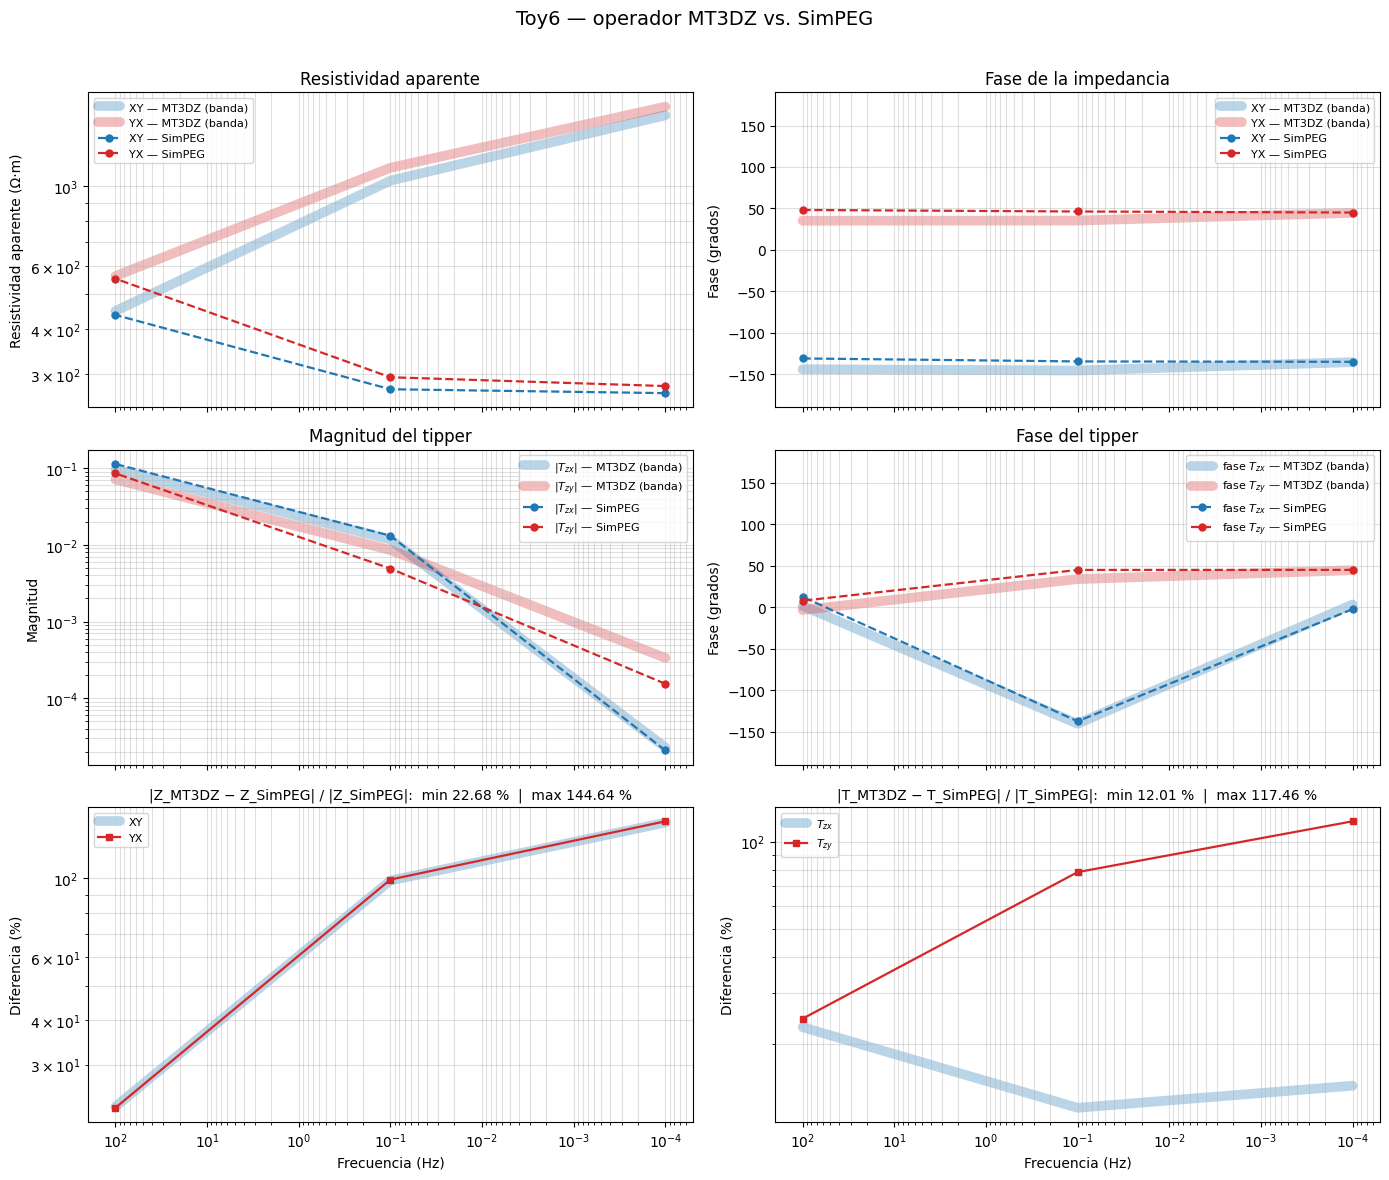

In [5]:
# 4) Figura unica de comparacion
#    Operador MT3DZ: banda gruesa translucida.  SimPEG: linea a guiones encima.
#    Donde SimPEG cae dentro de la banda, las dos soluciones coinciden.

c_xy, c_yx = "tab:blue", "tab:red"

kw_op = dict(linestyle="-", linewidth=7, alpha=0.30, solid_capstyle="round", zorder=1)
kw_sp = dict(linestyle="--", linewidth=1.6, marker="o", markersize=5, zorder=3)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
(ax_rho, ax_phi), (ax_tmag, ax_tphi), (ax_dz, ax_dt) = axes

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy_op, color=c_xy, label="XY — MT3DZ (banda)", **kw_op)
ax_rho.plot(frec, rho_yx_op, color=c_yx, label="YX — MT3DZ (banda)", **kw_op)
ax_rho.plot(frec, rho_xy_sp, color=c_xy, label="XY — SimPEG", **kw_sp)
ax_rho.plot(frec, rho_yx_sp, color=c_yx, label="YX — SimPEG", **kw_sp)
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.set_title("Resistividad aparente")

# --- Fase de la impedancia
ax_phi.plot(frec, phi_xy_op, color=c_xy, label="XY — MT3DZ (banda)", **kw_op)
ax_phi.plot(frec, phi_yx_op, color=c_yx, label="YX — MT3DZ (banda)", **kw_op)
ax_phi.plot(frec, phi_xy_sp, color=c_xy, label="XY — SimPEG", **kw_sp)
ax_phi.plot(frec, phi_yx_sp, color=c_yx, label="YX — SimPEG", **kw_sp)
ax_phi.set_ylim(-190, 190)
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_title("Fase de la impedancia")

# --- Magnitud del tipper
ax_tmag.plot(frec, mag_tzx_op, color=c_xy, label=r"$|T_{zx}|$ — MT3DZ (banda)", **kw_op)
ax_tmag.plot(frec, mag_tzy_op, color=c_yx, label=r"$|T_{zy}|$ — MT3DZ (banda)", **kw_op)
ax_tmag.plot(frec, mag_tzx_sp, color=c_xy, label=r"$|T_{zx}|$ — SimPEG", **kw_sp)
ax_tmag.plot(frec, mag_tzy_sp, color=c_yx, label=r"$|T_{zy}|$ — SimPEG", **kw_sp)
ax_tmag.set_yscale("log")
ax_tmag.set_ylabel("Magnitud")
ax_tmag.set_title("Magnitud del tipper")

# --- Fase del tipper
ax_tphi.plot(frec, phi_tzx_op, color=c_xy, label=r"fase $T_{zx}$ — MT3DZ (banda)", **kw_op)
ax_tphi.plot(frec, phi_tzy_op, color=c_yx, label=r"fase $T_{zy}$ — MT3DZ (banda)", **kw_op)
ax_tphi.plot(frec, phi_tzx_sp, color=c_xy, label=r"fase $T_{zx}$ — SimPEG", **kw_sp)
ax_tphi.plot(frec, phi_tzy_sp, color=c_yx, label=r"fase $T_{zy}$ — SimPEG", **kw_sp)
ax_tphi.set_ylim(-190, 190)
ax_tphi.set_ylabel("Fase (grados)")
ax_tphi.set_title("Fase del tipper")

# --- Diferencia relativa de la impedancia
ax_dz.plot(frec, dif_Z_xy, color=c_xy, label="XY", **kw_op)
ax_dz.plot(frec, dif_Z_yx, color=c_yx, marker="s", markersize=5, linewidth=1.6,
           linestyle="-", zorder=3, label="YX")
ax_dz.set_yscale("log")
ax_dz.set_ylabel("Diferencia (%)")
ax_dz.set_xlabel("Frecuencia (Hz)")
ax_dz.set_title(
    f"|Z_MT3DZ − Z_SimPEG| / |Z_SimPEG|:  min {np.nanmin([dif_Z_xy.min(), dif_Z_yx.min()]):.2f} %"
    f"  |  max {np.nanmax([dif_Z_xy.max(), dif_Z_yx.max()]):.2f} %",
    fontsize=10,
)

# --- Diferencia relativa del tipper
ax_dt.plot(frec, dif_T_zx, color=c_xy, label=r"$T_{zx}$", **kw_op)
ax_dt.plot(frec, dif_T_zy, color=c_yx, marker="s", markersize=5, linewidth=1.6,
           linestyle="-", zorder=3, label=r"$T_{zy}$")
ax_dt.set_yscale("log")
ax_dt.set_ylabel("Diferencia (%)")
ax_dt.set_xlabel("Frecuencia (Hz)")
ax_dt.set_title(
    f"|T_MT3DZ − T_SimPEG| / |T_SimPEG|:  min {np.nanmin([dif_T_zx.min(), dif_T_zy.min()]):.2f} %"
    f"  |  max {np.nanmax([dif_T_zx.max(), dif_T_zy.max()]):.2f} %",
    fontsize=10,
)

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(loc="best", fontsize=8)

# El eje x es compartido: basta invertirlo una vez
ax_rho.invert_xaxis()

fig.suptitle("Toy6 — operador MT3DZ vs. SimPEG", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("MT3DZ_vs_SimPEG_Toy6.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# 5) Metricas de error del operador MT3DZ respecto a SimPEG

def metricas_error(operador, simpeg, nombre="Variable", unidad="Ω·m"):
    """MAE, RMSE y MAPE descartando NaN, inf y valores de referencia casi nulos."""
    operador = np.asarray(operador, dtype=float)
    simpeg = np.asarray(simpeg, dtype=float)

    mask = (
        np.isfinite(operador)
        & np.isfinite(simpeg)
        & (np.abs(simpeg) > 1e-12)
    )

    n_desc = operador.size - mask.sum()

    error = operador[mask] - simpeg[mask]

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / simpeg[mask])) * 100

    print(f"\n{nombre}   (n={mask.sum()}, descartados={n_desc})")
    print(f"MAE  = {mae:.4f} {unidad}")
    print(f"RMSE = {rmse:.4f} {unidad}")
    print(f"MAPE = {mape:.2f} %")

    return mae, rmse, mape


print("=" * 60)
print("RESISTIVIDAD APARENTE")
print("=" * 60)
metricas_error(rho_xy_op, rho_xy_sp, nombre="Resistividad aparente XY")
metricas_error(rho_yx_op, rho_yx_sp, nombre="Resistividad aparente YX")

print("\n" + "=" * 60)
print("FASE")
print("=" * 60)
metricas_error(phi_xy_op, phi_xy_sp, nombre="Fase XY", unidad="grados")
metricas_error(phi_yx_op, phi_yx_sp, nombre="Fase YX", unidad="grados")

print("\n" + "=" * 60)
print("TIPPER (magnitud)")
print("=" * 60)
metricas_error(mag_tzx_op, mag_tzx_sp, nombre="|Tzx|", unidad="")
metricas_error(mag_tzy_op, mag_tzy_sp, nombre="|Tzy|", unidad="")

RESISTIVIDAD APARENTE

Resistividad aparente XY   (n=3, descartados=0)
MAE  = 693.9520 Ω·m
RMSE = 874.0923 Ω·m
MAPE = 258.46 %

Resistividad aparente YX   (n=3, descartados=0)
MAE  = 741.5651 Ω·m
RMSE = 932.2896 Ω·m
MAPE = 260.89 %

FASE

Fase XY   (n=3, descartados=0)
MAE  = 8.1089 grados
RMSE = 9.8039 grados
MAPE = 6.12 %

Fase YX   (n=3, descartados=0)
MAE  = 8.1111 grados
RMSE = 9.8007 grados
MAPE = 17.17 %

TIPPER (magnitud)

|Tzx|   (n=3, descartados=0)
MAE  = 0.0061 
RMSE = 0.0098 
MAPE = 11.90 %

|Tzy|   (n=3, descartados=0)
MAE  = 0.0060 
RMSE = 0.0085 
MAPE = 69.42 %


(0.0060348223808187815, 0.008512162260408565, 69.42429039739149)

## Cómo leer la comparación

- El **operador MT3DZ** se dibuja como banda gruesa translúcida y **SimPEG** como línea a guiones
  encima: donde SimPEG cae dentro de la banda, las dos soluciones coinciden.
- La fila inferior es la **diferencia relativa respecto a SimPEG** (%), en escala logarítmica.
- La diferencia crece hacia las **frecuencias bajas**: a $10^{-4}$ Hz el *skin depth* supera con
  holgura el tamaño del dominio de `mesh_Toy6_MT.json`, así que la respuesta queda dominada por los
  bordes. Es un límite de la **malla**, no una discrepancia de formulación: para comparar a esas
  frecuencias hay que agrandar el dominio y el *padding*.
- En el **tipper** conviene mirar además la magnitud absoluta: cuando $|T|$ es muy pequeño, un
  error relativo grande sigue siendo un error absoluto diminuto.

### Archivos generados

| Archivo | Contenido |
|---|---|
| `MT3DZ_vs_SimPEG_Toy6.png` | comparación de resistividad aparente, fase y tipper |